##### ZEPTO Inventory Analysis Project

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings("ignore")

In [6]:
#viewing the file

df = pd.read_excel(r"C:\Users\Dell\Desktop\zepto_v1.xlsx")

df.head()

,Category,name,mrp,discountPercent,availableQuantity,discountedSellingPrice,weightInGms,outOfStock,quantity
0,Fruits & Vegetables,Onion,2500,16,3,2100,1000,False,1
1,Fruits & Vegetables,Tomato Hybrid,4200,16,3,3500,1000,False,1
2,Fruits & Vegetables,Tender Coconut,5100,15,3,4300,58,False,1
3,Fruits & Vegetables,Coriander Leaves,2000,15,3,1700,100,False,100
4,Fruits & Vegetables,Ladies Finger,1400,14,3,1200,250,False,250


In [7]:
#checking the structure

df.shape

(3732, 9)

In [8]:
#checking the datatypes

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3732 entries, 0 to 3731
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Category                3732 non-null   object
 1   name                    3732 non-null   object
 2   mrp                     3732 non-null   int64 
 3   discountPercent         3732 non-null   int64 
 4   availableQuantity       3732 non-null   int64 
 5   discountedSellingPrice  3732 non-null   int64 
 6   weightInGms             3732 non-null   int64 
 7   outOfStock              3732 non-null   bool  
 8   quantity                3732 non-null   int64 
dtypes: bool(1), int64(6), object(2)
memory usage: 237.0+ KB


In [9]:
#checking statistical measures

df.describe(include = "all")

,Category,name,mrp,discountPercent,availableQuantity,discountedSellingPrice,weightInGms,outOfStock,quantity
count,3732,3732,3732.000000,3732.000000,3732.000000,3732.000000,3732.000000,3732,3732.000000
unique,14,1681,NaN,NaN,NaN,NaN,NaN,2,NaN
top,Cooking Essentials,Mother's Recipe Tamarind Paste,NaN,NaN,NaN,NaN,NaN,False,NaN
freq,514,10,NaN,NaN,NaN,NaN,NaN,3279,NaN
mean,NaN,NaN,15680.117899,7.617095,4.008574,14192.834941,387.843783,NaN,213.270900
std,NaN,NaN,16088.807618,9.211733,2.203511,13850.726265,678.096509,NaN,194.730976
min,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000
25%,NaN,NaN,6000.000000,0.000000,2.000000,5500.000000,100.000000,NaN,50.000000
50%,NaN,NaN,11000.000000,6.000000,5.000000,10400.000000,225.000000,NaN,186.000000
75%,NaN,NaN,20000.000000,10.000000,6.000000,18400.000000,450.000000,NaN,340.000000


In [10]:
#checking null values

df.isnull().sum()

Category                  0
name                      0
mrp                       0
discountPercent           0
availableQuantity         0
discountedSellingPrice    0
weightInGms               0
outOfStock                0
quantity                  0
dtype: int64

In [11]:
#checking all product categories

df["Category"].value_counts()

Category
Cooking Essentials       514
Munchies                 514
Packaged Food            388
Ice Cream & Desserts     388
Chocolates & Candies     388
Personal Care            344
Paan Corner              344
Home & Cleaning          194
Biscuits                 147
Dairy, Bread & Batter    129
Beverages                129
Health & Hygiene          97
Fruits & Vegetables       93
Meats, Fish & Eggs        63
Name: count, dtype: int64

In [12]:
#checking in and out of stock products

df.groupby(["Category", "outOfStock"])["quantity"].sum()

Category               outOfStock
Beverages              False         23789
                       True           5054
Biscuits               False         19302
                       True           6707
Chocolates & Candies   False         91709
                       True          11781
Cooking Essentials     False         93460
                       True          13029
Dairy, Bread & Batter  False         23789
                       True           5054
Fruits & Vegetables    False         14679
                       True           1351
Health & Hygiene       False          7450
                       True            604
Home & Cleaning        False         23055
                       True           3054
Ice Cream & Desserts   False         91709
                       True          11781
Meats, Fish & Eggs     False         13357
                       True           3874
Munchies               False         93460
                       True          13029
Paan Corner         

In [13]:
#checking product names

df["name"].value_counts()

name
Mother's Recipe Tamarind Paste                       10
Amul Delicious Fat Spread - Cholesterol Free         10
Arden Eggs White                                     10
Quaker Oats                                          10
Saffola Veggie Twist Masala Oats                     10
                                                     ..
Godrej Real Good Chicken Curry Cut                    1
TGFC Chicken Curry Cut Fresh                          1
Godrej Real Good Chicken Breast Boneless              1
Fresh Chicken Boneless Cubes (Halal)                  1
Dabur Honitus Herbal Cough Remedy Ayurvedic Syrup     1
Name: count, Length: 1681, dtype: int64

In [14]:
#checking invalid values for sanity check so we can drop accordingly

df[df["discountedSellingPrice"]<= 0]

,Category,name,mrp,discountPercent,availableQuantity,discountedSellingPrice,weightInGms,outOfStock,quantity
3606,Home & Cleaning,Cherry Blossom Liquid Shoe Polish Neutral,0,0,1,0,75,False,75


In [15]:
#dropping the above value

#confirming the index

df.iloc[3606]

Category                                             Home & Cleaning
name                      Cherry Blossom Liquid Shoe Polish Neutral 
mrp                                                                0
discountPercent                                                    0
availableQuantity                                                  1
discountedSellingPrice                                             0
weightInGms                                                       75
outOfStock                                                     False
quantity                                                          75
Name: 3606, dtype: object

In [16]:
df = df.drop(df.index[3606]).reset_index(drop = True)

#value dropped and index reset done 

In [17]:
df.iloc[3606]

Category                    Home & Cleaning
name                      Om Bhakti Kumkum 
mrp                                    1200
discountPercent                           0
availableQuantity                         6
discountedSellingPrice                 1200
weightInGms                              15
outOfStock                            False
quantity                                 15
Name: 3606, dtype: object

In [18]:
#the currency is in pesa not rupees so converting in rupees

df[["mrp","discountPercent","discountedSellingPrice"]] = df[["mrp","discountPercent","discountedSellingPrice"]]/100

In [19]:
#converted in Rs. value 

df.head()

,Category,name,mrp,discountPercent,availableQuantity,discountedSellingPrice,weightInGms,outOfStock,quantity
0,Fruits & Vegetables,Onion,25.0,0.16,3,21.0,1000,False,1
1,Fruits & Vegetables,Tomato Hybrid,42.0,0.16,3,35.0,1000,False,1
2,Fruits & Vegetables,Tender Coconut,51.0,0.15,3,43.0,58,False,1
3,Fruits & Vegetables,Coriander Leaves,20.0,0.15,3,17.0,100,False,100
4,Fruits & Vegetables,Ladies Finger,14.0,0.14,3,12.0,250,False,250


# Q1 - Find the top 10 best value products based on discount Percentage.

In [20]:
df[["name","Category","mrp","discountPercent"]].sort_values(by = "discountPercent", ascending = False).head(10)

,name,Category,mrp,discountPercent
2619,Dukes Waffy Strawberry Wafers,Biscuits,45.0,0.51
2608,Dukes Waffy Chocolate Wafers,Biscuits,45.0,0.51
2615,Dukes Waffy Orange Wafers,Biscuits,45.0,0.51
1191,RRO Cheddar Block Cheese,"Dairy, Bread & Batter",295.0,0.50
1195,RRO Fresh Ricotta,"Dairy, Bread & Batter",275.0,0.50
1197,RRO Mozzarella Pizza Cheese,"Dairy, Bread & Batter",275.0,0.50
1643,Moi Soi Black Bean Sauce - Dip Spread Stir Fr...,Packaged Food,280.0,0.50
1200,RRO Burrata Cheese,"Dairy, Bread & Batter",250.0,0.50
1326,RRO Mozzarella Pizza Cheese,Beverages,275.0,0.50
1213,RRO Mascarpone Cheese,"Dairy, Bread & Batter",355.0,0.50


# Q2 - What are the products with high MRP but out of stock?

In [21]:
df.loc[(df["outOfStock"] == True) & (df["mrp"] > 300)].sort_values(by = "mrp", ascending = False)

#using loc method

,Category,name,mrp,discountPercent,availableQuantity,discountedSellingPrice,weightInGms,outOfStock,quantity
580,Cooking Essentials,Patanjali Cow's Ghee,565.0,0.00,0,565.0,1000,True,1
1094,Munchies,Patanjali Cow's Ghee,565.0,0.00,0,565.0,1000,True,1
3096,Personal Care,"MamyPoko Pants Standard Diapers, Extra Large (...",399.0,0.07,0,369.0,26,True,26
3440,Paan Corner,"MamyPoko Pants Standard Diapers, Extra Large (...",399.0,0.07,0,369.0,26,True,26
553,Cooking Essentials,Aashirvaad Atta With Mutigrains,315.0,0.08,0,287.0,5000,True,5
1067,Munchies,Aashirvaad Atta With Mutigrains,315.0,0.08,0,287.0,5000,True,5
573,Cooking Essentials,Everest Kashmiri Lal Chilli Powder,310.0,0.10,0,279.0,500,True,500
1087,Munchies,Everest Kashmiri Lal Chilli Powder,310.0,0.10,0,279.0,500,True,500


In [22]:
df.query("`outOfStock` == True & `mrp` >300").sort_values('mrp', ascending = False)

#using query method

,Category,name,mrp,discountPercent,availableQuantity,discountedSellingPrice,weightInGms,outOfStock,quantity
580,Cooking Essentials,Patanjali Cow's Ghee,565.0,0.00,0,565.0,1000,True,1
1094,Munchies,Patanjali Cow's Ghee,565.0,0.00,0,565.0,1000,True,1
3096,Personal Care,"MamyPoko Pants Standard Diapers, Extra Large (...",399.0,0.07,0,369.0,26,True,26
3440,Paan Corner,"MamyPoko Pants Standard Diapers, Extra Large (...",399.0,0.07,0,369.0,26,True,26
553,Cooking Essentials,Aashirvaad Atta With Mutigrains,315.0,0.08,0,287.0,5000,True,5
1067,Munchies,Aashirvaad Atta With Mutigrains,315.0,0.08,0,287.0,5000,True,5
573,Cooking Essentials,Everest Kashmiri Lal Chilli Powder,310.0,0.10,0,279.0,500,True,500
1087,Munchies,Everest Kashmiri Lal Chilli Powder,310.0,0.10,0,279.0,500,True,500


# Q3 - Calculate estimate revenue for each catagory.

In [65]:
df.groupby("Category").apply(
    lambda x : (x["availableQuantity"]*x["discountedSellingPrice"]).sum()).sort_values(
    ascending = True)

#to calculate, revenue (internal calculation), lambda function was used, we could add new column as revenue and then do groupby too.... 

Category
Fruits & Vegetables       10846.0
Meats, Fish & Eggs        20693.0
Biscuits                  25007.6
Beverages                 55051.0
Dairy, Bread & Batter     55051.0
Health & Hygiene          64180.0
Home & Cleaning          122661.0
Chocolates & Candies     224385.0
Ice Cream & Desserts     224385.0
Packaged Food            224385.0
Paan Corner              270849.0
Personal Care            270849.0
Cooking Essentials       337369.0
Munchies                 337369.0
dtype: float64

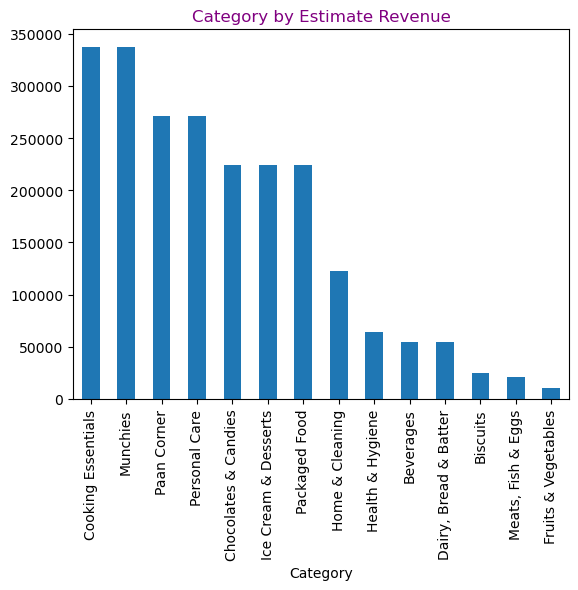

In [75]:
df.groupby("Category").apply(
    lambda x : (x["availableQuantity"]*x["discountedSellingPrice"]).sum()).sort_values(
    ascending = False).plot(kind = 'bar')

plt.title('Category by Estimate Revenue', color = 'Purple')
plt.show()

# Q4 - Find all products where MRP is above 500 and discount is less than 10%.

In [76]:
df.loc[(df["mrp"]>500) & (df["discountPercent"]< 10)].sort_values(by = 'mrp', ascending = False)

,Category,name,mrp,discountPercent,availableQuantity,discountedSellingPrice,weightInGms,outOfStock,quantity,price_per_gram,NewCatagory
517,Cooking Essentials,Borges Extra Light Olive Oil Bottle,2600.0,0.46,6,1399.0,2000,False,2,0.769231,low
1031,Munchies,Borges Extra Light Olive Oil Bottle,2600.0,0.46,6,1399.0,2000,False,2,0.769231,low
3016,Personal Care,Pampers Pants - Large,1549.0,0.45,3,849.0,82,False,82,0.052937,medium
3360,Paan Corner,Pampers Pants - Large,1549.0,0.45,3,849.0,82,False,82,0.052937,medium
363,Cooking Essentials,Praakritik Natural Desi Gir Cow A2 Ghee,1450.0,0.10,6,1305.0,540,False,540,0.372414,high
...,...,...,...,...,...,...,...,...,...,...,...
624,Munchies,Amul Ghee (Tin),520.0,0.02,6,509.0,1000,False,1,1.923077,low
110,Cooking Essentials,Amul Ghee (Tin),520.0,0.02,6,509.0,1000,False,1,1.923077,low
2584,"Meats, Fish & Eggs",Fresh Mutton Mince - Kheema (Halal),515.0,0.03,1,495.0,500,False,500,0.970874,high
621,Munchies,Amul Pure Ghee (Pouch),505.0,0.01,2,499.0,1000,False,1,1.980198,low


# Q-5 Identify the top 5 categories offering the highest average discount percentage.

In [77]:
df.groupby("Category")["discountPercent"].mean().sort_values(ascending = False).head()

Category
Fruits & Vegetables     0.154624
Meats, Fish & Eggs      0.110317
Chocolates & Candies    0.083247
Ice Cream & Desserts    0.083247
Packaged Food           0.083247
Name: discountPercent, dtype: float64

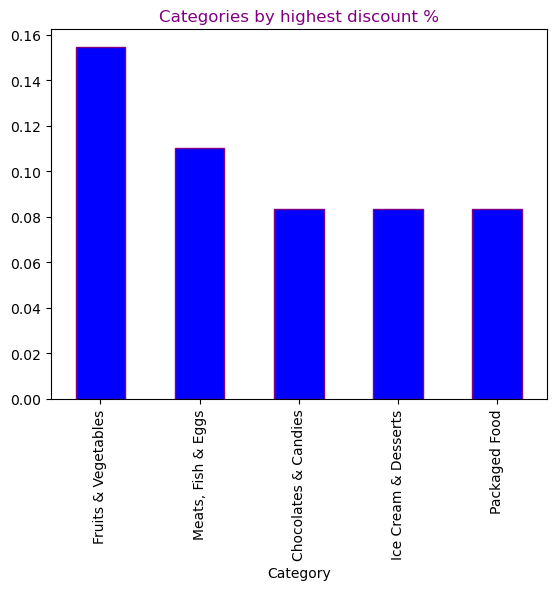

In [78]:
df.groupby("Category")["discountPercent"].mean().sort_values(ascending = False).head().plot(
    kind = 'bar', color = 'blue', edgecolor = 'purple')

plt.title('Categories by highest discount %', color = 'purple')
plt.show()

# Q-6 Find the Price per gram for products above 100 gm and sort by best value.

In [79]:
df['price_per_gram'] = df["weightInGms"]/df["mrp"]

df.head()

,Category,name,mrp,discountPercent,availableQuantity,discountedSellingPrice,weightInGms,outOfStock,quantity,price_per_gram,NewCatagory
0,Fruits & Vegetables,Onion,25.0,0.16,3,21.0,1000,False,1,40.000000,low
1,Fruits & Vegetables,Tomato Hybrid,42.0,0.16,3,35.0,1000,False,1,23.809524,low
2,Fruits & Vegetables,Tender Coconut,51.0,0.15,3,43.0,58,False,1,1.137255,low
3,Fruits & Vegetables,Coriander Leaves,20.0,0.15,3,17.0,100,False,100,5.000000,medium
4,Fruits & Vegetables,Ladies Finger,14.0,0.14,3,12.0,250,False,250,17.857143,medium


In [80]:
df.loc[df['weightInGms']>100].sort_values(by = 'price_per_gram', ascending = True)

,Category,name,mrp,discountPercent,availableQuantity,discountedSellingPrice,weightInGms,outOfStock,quantity,price_per_gram,NewCatagory
2909,Personal Care,"L'Oreal Paris Excellence Creme Hair Color, 4.2...",620.0,0.00,6,620.0,172,False,172,0.277419,medium
2850,Personal Care,"L'Oreal Paris Excellence Creme Hair Color, 1 B...",620.0,0.00,1,620.0,172,False,172,0.277419,medium
3314,Paan Corner,"L'Oreal Paris Excellence Creme Hair Color, 4 N...",620.0,0.00,1,620.0,172,False,172,0.277419,medium
2857,Personal Care,"L'Oreal Paris Excellence Creme Hair Color, 3 D...",620.0,0.00,6,620.0,172,False,172,0.277419,medium
3253,Paan Corner,"L'Oreal Paris Excellence Creme Hair Color, 4.2...",620.0,0.00,6,620.0,172,False,172,0.277419,medium
...,...,...,...,...,...,...,...,...,...,...,...
609,Munchies,Tata Salt,24.0,0.00,6,24.0,1000,False,1,41.666667,low
20,Fruits & Vegetables,Onion,68.0,0.16,3,57.0,3000,False,3,44.117647,low
1064,Munchies,Aashirvaad Iodised Salt,22.0,0.13,0,19.0,1000,True,1,45.454545,low
550,Cooking Essentials,Aashirvaad Iodised Salt,22.0,0.13,0,19.0,1000,True,1,45.454545,low


# Q-7 Group the products into catagories like low, medium, Bulk.

In [81]:
#creating NewCatagory Column

labels = ['low','medium','high']

df['NewCatagory'] = pd.qcut(df['quantity'], q = 3, labels = labels)

df.head()

,Category,name,mrp,discountPercent,availableQuantity,discountedSellingPrice,weightInGms,outOfStock,quantity,price_per_gram,NewCatagory
0,Fruits & Vegetables,Onion,25.0,0.16,3,21.0,1000,False,1,40.000000,low
1,Fruits & Vegetables,Tomato Hybrid,42.0,0.16,3,35.0,1000,False,1,23.809524,low
2,Fruits & Vegetables,Tender Coconut,51.0,0.15,3,43.0,58,False,1,1.137255,low
3,Fruits & Vegetables,Coriander Leaves,20.0,0.15,3,17.0,100,False,100,5.000000,medium
4,Fruits & Vegetables,Ladies Finger,14.0,0.14,3,12.0,250,False,250,17.857143,medium


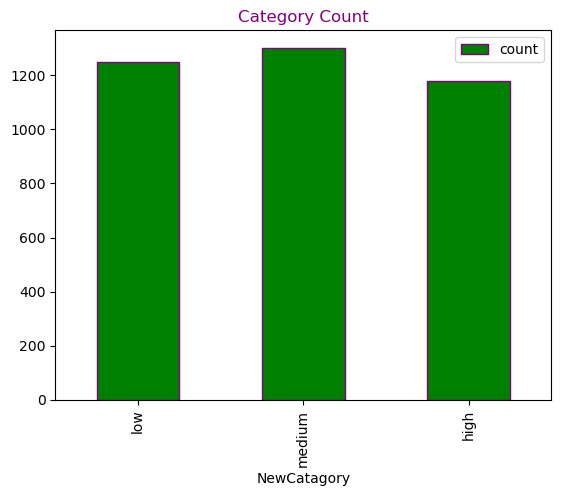

In [84]:
df.groupby('NewCatagory').agg(count = ('NewCatagory', 'count')).plot(
    kind = 'bar', color = 'green', edgecolor = 'purple')

plt.title('Category Count', color = 'purple')
plt.show()

# Q-8 What is total inventory weight per catagory?

In [40]:
df.groupby("Category").apply(lambda x : (x["weightInGms"]*x["availableQuantity"]).sum())

Category
Beverages                 143735
Biscuits                   84431
Chocolates & Candies      490797
Cooking Essentials       1404654
Dairy, Bread & Batter     143735
Fruits & Vegetables        91794
Health & Hygiene          142904
Home & Cleaning           373161
Ice Cream & Desserts      490797
Meats, Fish & Eggs         48016
Munchies                 1404654
Paan Corner               348187
Packaged Food             490797
Personal Care             348187
dtype: int64

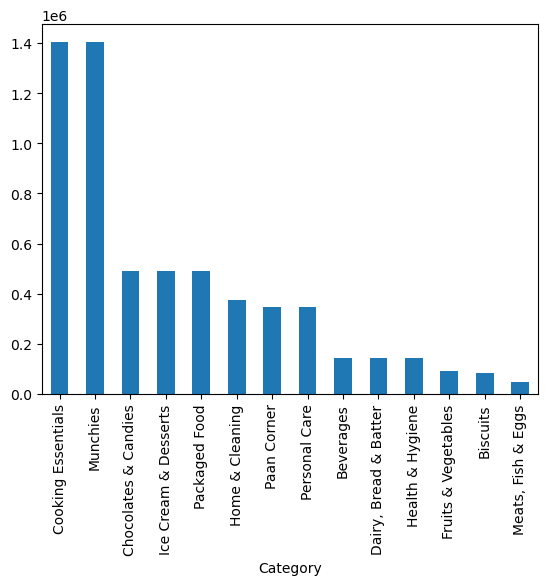

In [36]:
df.groupby("Category").apply(
    lambda x : (x["weightInGms"]*x["availableQuantity"]).sum()).sort_values(
    ascending = 
    ).plot(kind = 'bar')

plt.show()

## Key takeaways

##### Discount strategy should be category-specific, not uniform

##### Premium products need availability, not discounts

##### Bulk products offer the best customer value and higher order sizes

##### Inventory optimization is key for both revenue growth and cost control